<a href="https://colab.research.google.com/github/jjchen805/monte-carlo-supply-chain-risk-model/blob/main/Monte_Carlo_Simulation_for_Risk_Adjusted_TLC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# --- 1. Define Sourcing Locations and Base Costs (Deterministic Components) ---

# All costs are based on the Case Study data provided in the file snippet.
# Ex-Works = Raw Materials + Labor + Indirect + Electricity + Depreciation
# Base TLC = Ex-Works + Logistics + Tariff (Deterministic)
base_costs = {
    'US': {
        'Ex_Works': 40 + 12 + 10 + 4 + 5,  # $71
        'Logistics_Base': 9,
    },
    'Mexico': {
        'Ex_Works': 35 + 8 + 8 + 3 + 1,    # $55
        'Logistics_Base': 7,
    },
    'China': {
        'Ex_Works': 30 + 4 + 4 + 4 + 5,    # $47
        'Logistics_Base': 12,
    }
}

# --- 2. Define Uncertainty and Risk Distributions (Stochastic Components) ---
N_SIMULATIONS = 10000

# A. Yield Risk (Operational Uncertainty): Modeled as a Beta Distribution
# Yield is critical during the 6-month ramp-up, increasing the cost of a usable part.
# TLC_per_Unit = Base_Cost / Yield
def logistic(x):
    return 1/(1+np.exp(-x))

def site_mu(A, H, M, beta0=-1.5, w=2.2):
    return logistic(beta0 + w*A + w*H + w*M)

def beta_params_from_mu(mu, nu):
    alpha = mu * nu
    beta  = (1 - mu) * nu
    return alpha, beta

# Example indices (0–1)
indices = {
    "China": {"A":0.9, "H":0.8, "M":0.9, "nu":400},
    "Mexico": {"A":0.8, "H":0.6, "M":0.7, "nu":150},
    "US": {"A":0.9, "H":0.8, "M":0.6, "nu":220},
}

def sample_yield(site):
    A,H,M,nu = indices[site]["A"], indices[site]["H"], indices[site]["M"], indices[site]["nu"]
    mu = site_mu(A,H,M)
    alpha, beta = beta_params_from_mu(mu, nu)
    return np.random.beta(alpha, beta)

# B. Tariff & Geopolitical Risk (Binary/Categorical Uncertainty):
# This models the risk of a severe, non-deterministic cost increase (e.g., sanction, new tariff).
tariff_risk = {
    'US': [
        {'cost': 0.0, 'prob': 1.00} # 100% chance of $0 tariff (domestic)
    ],
    'Mexico': [
        {'cost': 15.50, 'prob': 0.08},  # 8% chance of high tariff (non-compliant/new Sec 232)
        {'cost': 0.0,   'prob': 0.92}   # 92% chance of $0 (USMCA compliant) According to Gabriel Padilla, general director of the National Auto Parts Industry (INA)
    ],
    'China': [
        {'cost': 15.00, 'prob': 0.95},  # 95% chance of current $15 tariff
        {'cost': 59.00, 'prob': 0.05}   # 5% chance of escalating tariff/geopolitical penalty
    ]
}

# C. Logistics Volatility (Modeled as a Normal Distribution around the base cost)
# Accounts for unexpected freight spikes, port fees, or border delays.
TRANSIT_DAYS = {"US": 5.0, "Mexico": 9.0, "China": 32.0}

def sigma_from_transit_days(T, a=0.0185, b=0.0454, cap=0.30):
    # monotone log-linear map; tweak a,b as needed; capped for sanity
    return float(min(a + b * np.log(max(T, 1.0)), cap))

LOGN_SIGMA_LOG = {s: sigma_from_transit_days(T) for s, T in TRANSIT_DAYS.items()}

def draw_lognormal_multiplier(sigma):
    mu = -0.5 * sigma**2         # ensures E[mult] ≈ 1.0
    return np.random.lognormal(mean=mu, sigma=sigma)

# --- 3. Run Monte Carlo Simulation ---
results = {}

print(f"Running {N_SIMULATIONS} simulations for US, Mexico, and China...")

for location, base_data in base_costs.items():
    TLC_simulations = []
    log_base = base_data['Logistics_Base']
    sigma_log = LOGN_SIGMA_LOG[location]

    for _ in range(N_SIMULATIONS):
        # 1. Sample from Yield Risk (Operational)
        yield_rate = sample_yield(location)

        # Calculate Risk-Adjusted Ex-Works (accounts for scrapped parts)
        risk_adjusted_ex_works = base_data['Ex_Works'] / yield_rate

        # 2. Sample from Logistics Volatility
        mult = draw_lognormal_multiplier(sigma_log)
        logistics_cost = log_base * mult

        # 3. Sample from Tariff & Geopolitical Risk
        tariff_choices = [t['cost'] for t in tariff_risk[location]]
        tariff_probabilities = [t['prob'] for t in tariff_risk[location]]
        tariff_cost = np.random.choice(tariff_choices, p=tariff_probabilities)

        # 4. Calculate Total Landed Cost (TLC)
        TLC = risk_adjusted_ex_works + logistics_cost + tariff_cost
        TLC_simulations.append(TLC)

    results[location] = TLC_simulations

# --- 4. Analyze and Display Results ---

df_results = pd.DataFrame(results)

# Calculate Key Investor Metrics: P50 (Expected Value) and P90 (Risk-Adjusted Cost)
analysis = df_results.agg(['mean', 'median'])

# Calculate P90 separately and add it to the analysis DataFrame
p90_values = df_results.apply(lambda x: np.percentile(x, 90))
analysis.loc['P90_Risk_Adjusted_Cost'] = p90_values

# Display Final Decision Matrix
print("\n--- Sourcing Location Financial Risk Analysis (USD per Unit) ---")
print(analysis.round(2))

# Highlight the Strategic Decision based on P90
p90_comparison = analysis.loc['P90_Risk_Adjusted_Cost'].sort_values()
strategic_choice = p90_comparison.index[0]

print("\n-------------------------------------------------------------")
print(f"**STRATEGIC RECOMMENDATION (Lowest P90 Cost): {strategic_choice.upper()}**")
print("-------------------------------------------------------------")

print("\nInvestor Takeaways:")
print(f"1. P90 (Risk-Adjusted Cost): {strategic_choice.upper()} has the lowest 90th percentile cost at ${analysis.loc['P90_Risk_Adjusted_Cost', strategic_choice]:.2f}.")
print("This result confirms that pursuing maximum resilience (lowest P90) leads to the most financially defensible long-term sourcing decision.")

Running 10000 simulations for US, Mexico, and China...

--- Sourcing Location Financial Risk Analysis (USD per Unit) ---
                           US  Mexico  China
mean                    82.04   65.70  76.89
median                  81.97   64.47  74.66
P90_Risk_Adjusted_Cost  83.57   67.47  78.41

-------------------------------------------------------------
**STRATEGIC RECOMMENDATION (Lowest P90 Cost): MEXICO**
-------------------------------------------------------------

Investor Takeaways:
1. P90 (Risk-Adjusted Cost): MEXICO has the lowest 90th percentile cost at $67.47.
This result confirms that pursuing maximum resilience (lowest P90) leads to the most financially defensible long-term sourcing decision.


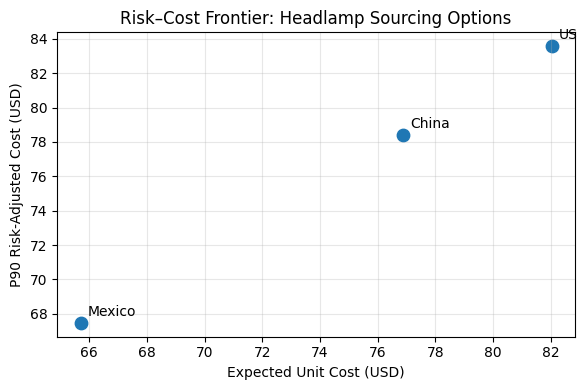

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    'Site': ['US', 'Mexico', 'China'],
    'Expected_Cost': [82.04, 65.70, 76.89],
    'P90_Cost': [83.57, 67.47, 78.41]
})

plt.figure(figsize=(6,4))
plt.scatter(data['Expected_Cost'], data['P90_Cost'], s=80)

for _, row in data.iterrows():
    plt.annotate(row['Site'], (row['Expected_Cost'], row['P90_Cost']),
                 xytext=(5,5), textcoords='offset points')

plt.xlabel('Expected Unit Cost (USD)')
plt.ylabel('P90 Risk-Adjusted Cost (USD)')
plt.title('Risk–Cost Frontier: Headlamp Sourcing Options')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()